# Healthcare Readmission Risk Prediction

End-to-end notebook: data understanding → cleaning → EDA → statistical tests → feature engineering → modeling (Logistic Regression, Random Forest, CatBoost) → model comparison → risk scoring → Power BI export.

Data files expected in `./data/diabetic_data.csv` and `./data/IDS_mapping.csv`.

## Setup & Imports

In [1]:
"""
Healthcare Readmission Risk Prediction — full pipeline
Run: python3 pipeline.py
"""
import warnings, json
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

OUT = "outputs"

## 02 LOAD DATA  (note: missing values are coded as '?', not blank)

In [2]:
df = pd.read_csv("data/diabetic_data.csv", na_values="?")
mapping_df = pd.read_csv("data/IDS_mapping.csv")
print("Main dataset shape:", df.shape)
print("Mapping dataset shape:", mapping_df.shape)

Main dataset shape: (101766, 50)
Mapping dataset shape: (67, 2)


## 03/04 UNDERSTANDING + QUALITY


Duplicate rows: 0
Duplicate encounter_id: 0
Unique patients: 71518 / total encounters: 101766

Missingness:
                    Missing_Count  Missing_Percentage
weight                     98569               96.86
max_glu_serum              96420               94.75
A1Cresult                  84748               83.28
medical_specialty          49949               49.08
payer_code                 40256               39.56
race                        2273                2.23
diag_3                      1423                1.40
diag_2                       358                0.35
diag_1                        21                0.02


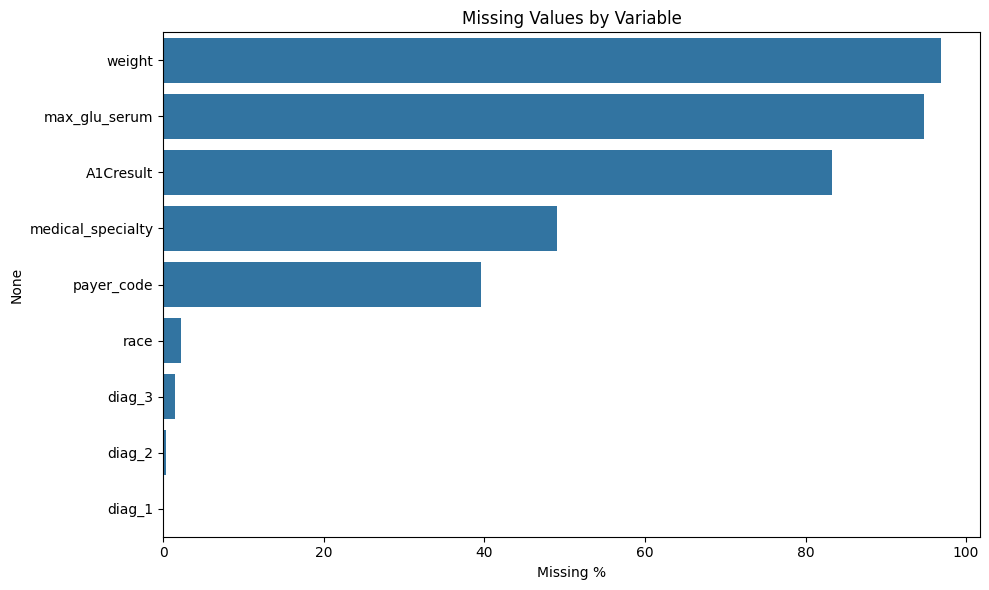


Zero-variance columns (candidates to drop): ['examide', 'citoglipton']


In [3]:
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate encounter_id:", df["encounter_id"].duplicated().sum())
print("Unique patients:", df["patient_nbr"].nunique(), "/ total encounters:", df["encounter_id"].nunique())

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("Missing_Count", ascending=False)
print("\nMissingness:\n", missing_summary[missing_summary.Missing_Count > 0])

plt.figure(figsize=(10, 6))
mp = missing_summary[missing_summary.Missing_Count > 0]
sns.barplot(x=mp["Missing_Percentage"], y=mp.index)
plt.title("Missing Values by Variable"); plt.xlabel("Missing %"); plt.tight_layout()
plt.savefig(f"{OUT}/01_missingness.png", dpi=110); plt.show()

# Also flag near-constant / no-info columns (only 1-2 distinct values incl NA)
low_variance_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print("\nZero-variance columns (candidates to drop):", low_variance_cols)

## 05 TARGET


Target distribution:
 early_readmission
0    90409
1    11357
Name: count, dtype: int64
early_readmission
0    88.84
1    11.16
Name: proportion, dtype: float64


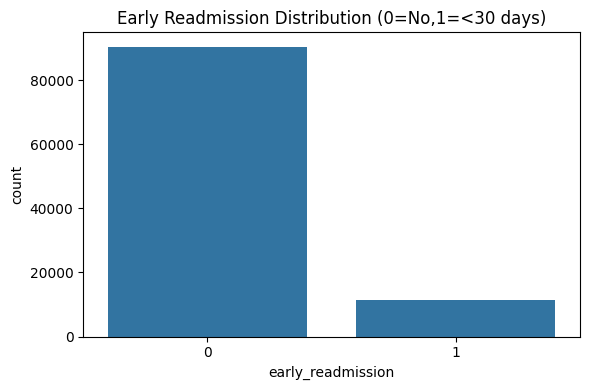

In [4]:
df["early_readmission"] = (df["readmitted"] == "<30").astype(int)
print("\nTarget distribution:\n", df["early_readmission"].value_counts())
print(df["early_readmission"].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="early_readmission")
plt.title("Early Readmission Distribution (0=No,1=<30 days)")
plt.tight_layout(); plt.savefig(f"{OUT}/02_target_dist.png", dpi=110); plt.show()

## 06 ID MAPPING

In [5]:
def build_mapping(mapping_df, key_col):
    # The file stacks three lookup tables in one CSV: the first table's header
    # is the real column header ("admission_type_id"); the other two tables
    # start with a row whose first cell literally contains their id-name.
    col0 = mapping_df.iloc[:, 0].astype(str)
    if key_col == mapping_df.columns[0]:
        start = 0
    else:
        start = mapping_df.index[col0 == key_col][0] + 1
    matches = mapping_df.index[(col0 == "discharge_disposition_id") |
                                (col0 == "admission_source_id")]
    later = [i for i in matches if i > start]
    end = min(later) if later else len(mapping_df)
    sub = mapping_df.iloc[start:end]
    sub = sub[sub.iloc[:, 0].notna()]
    d = {}
    for _, row in sub.iterrows():
        try:
            d[int(float(row.iloc[0]))] = row.iloc[1]
        except (ValueError, TypeError):
            continue
    return d

admission_mapping = build_mapping(mapping_df, "admission_type_id")
discharge_mapping = build_mapping(mapping_df, "discharge_disposition_id")
source_mapping = build_mapping(mapping_df, "admission_source_id")

df["admission_type"] = df["admission_type_id"].map(admission_mapping)
df["discharge_disposition"] = df["discharge_disposition_id"].map(discharge_mapping)
df["admission_source"] = df["admission_source_id"].map(source_mapping)

print("\nSample mapped values:")
print(df[["admission_type_id", "admission_type",
          "discharge_disposition_id", "discharge_disposition",
          "admission_source_id", "admission_source"]].head(5).to_string())


Sample mapped values:
   admission_type_id admission_type  discharge_disposition_id discharge_disposition  admission_source_id     admission_source
0                  6            NaN                        25            Not Mapped                    1   Physician Referral
1                  1      Emergency                         1    Discharged to home                    7       Emergency Room
2                  1      Emergency                         1    Discharged to home                    7       Emergency Room
3                  1      Emergency                         1    Discharged to home                    7       Emergency Room
4                  1      Emergency                         1    Discharged to home                    7       Emergency Room


## 07 CLEANING

In [6]:
# weight (96.9% missing) and max_glu_serum (94.7% missing) -> drop, too sparse to impute meaningfully
df = df.drop(columns=["weight", "max_glu_serum"])

df["A1Cresult"] = df["A1Cresult"].fillna("Not Tested")
df["medical_specialty"] = df["medical_specialty"].fillna("Unknown")
df["payer_code"] = df["payer_code"].fillna("Unknown")
df["race"] = df["race"].fillna("Unknown")
df["diag_1"] = df["diag_1"].fillna("Unknown")
df["diag_2"] = df["diag_2"].fillna("Unknown")
df["diag_3"] = df["diag_3"].fillna("Unknown")

# Discharge dispositions meaning "expired"/hospice -> these encounters cannot be readmitted
# meaningfully and are a known leakage/noise source for this dataset. We exclude them.
expired_hospice_ids = [11, 13, 14, 19, 20, 21]
before = len(df)
df = df[~df["discharge_disposition_id"].isin(expired_hospice_ids)].copy()
df = df.reset_index(drop=True)
print(f"\nDropped {before - len(df)} encounters with expired/hospice discharge (can't be meaningfully readmitted).")

remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print("\nRemaining missing after cleaning:\n", remaining_missing)


Dropped 2423 encounters with expired/hospice discharge (can't be meaningfully readmitted).

Remaining missing after cleaning:
 admission_type           5207
discharge_disposition    3691
admission_source         6570
dtype: int64


## 08-11 EDA


--- Readmission rate by age ---
           total  readmits  rate_pct
age                                
[20-30)    1649       236     14.31
[80-90)   16434      2065     12.57
[70-80)   25331      3054     12.06
[90-100)   2589       308     11.90
[60-70)   22059      2493     11.30
[30-40)    3764       424     11.26
[40-50)    9607      1024     10.66
[50-60)   17060      1667      9.77
[10-20)     690        40      5.80
[0-10)      160         3      1.88

--- by gender ---
                  total  readmits  rate_pct
gender                                    
Female           53454      6128     11.46
Male             45886      5186     11.30
Unknown/Invalid      3         0      0.00

--- by race ---
                  total  readmits  rate_pct
race                                      
Caucasian        74220      8556     11.53
AfricanAmerican  18772      2149     11.45
Hispanic          2017       212     10.51
Asian              628        65     10.35
Other             1472 

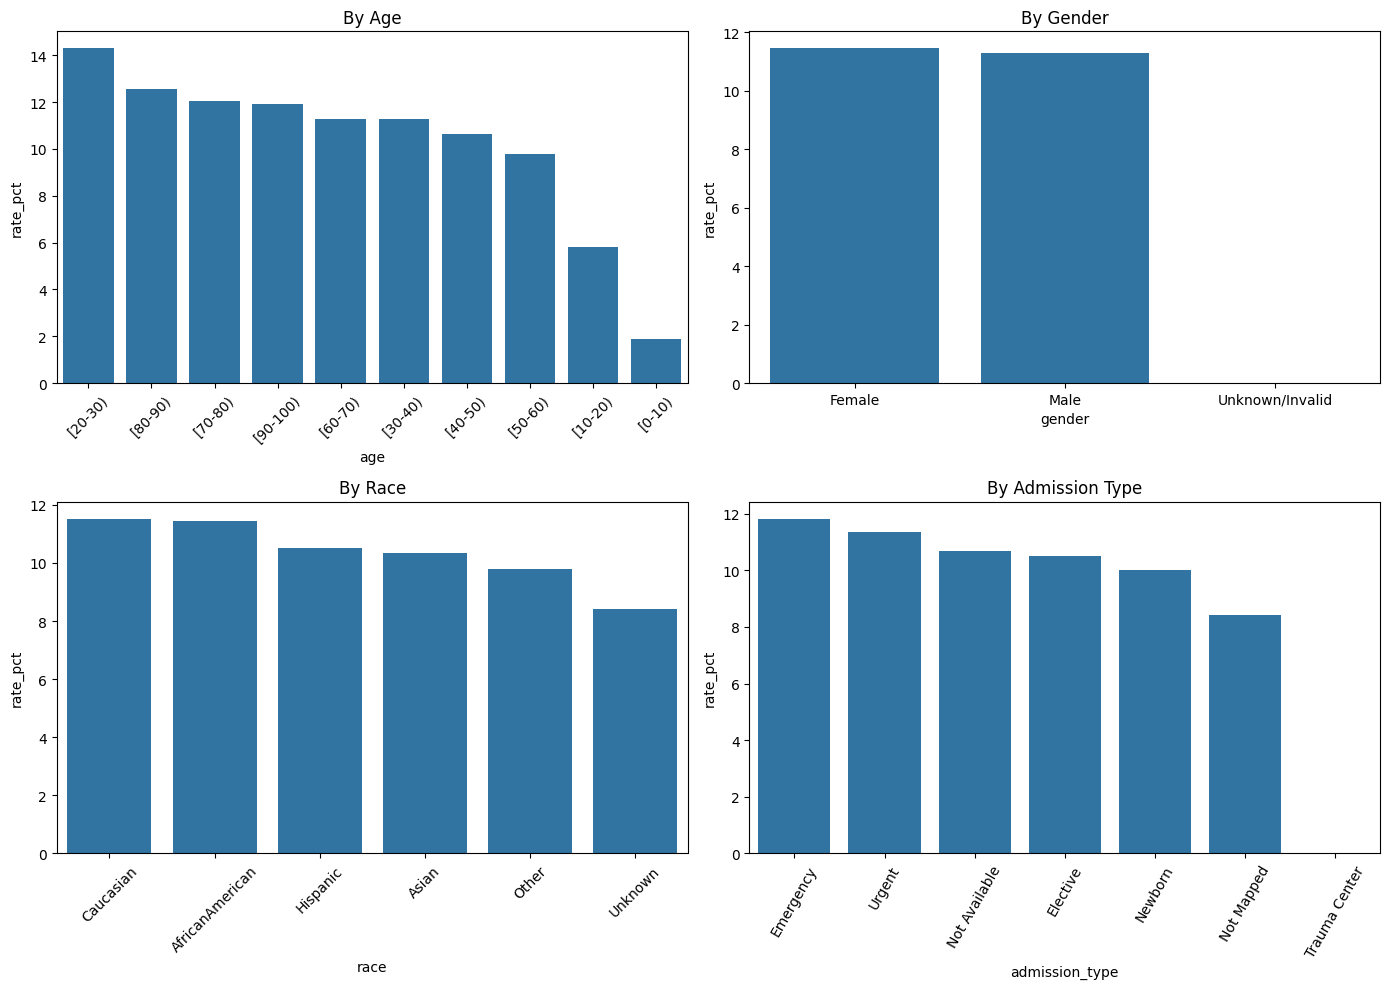


Numerical feature summary:
                       count       mean        std  min   25%   50%   75%  \
time_in_hospital    99343.0   4.379332   2.968409  1.0   2.0   4.0   6.0   
num_lab_procedures  99343.0  42.906929  19.610032  1.0  31.0  44.0  57.0   
num_procedures      99343.0   1.334236   1.702786  0.0   0.0   1.0   2.0   
num_medications     99343.0  15.979062   8.094909  1.0  10.0  15.0  20.0   
number_outpatient   99343.0   0.369246   1.265142  0.0   0.0   0.0   0.0   
number_emergency    99343.0   0.198444   0.937734  0.0   0.0   0.0   0.0   
number_inpatient    99343.0   0.630935   1.260428  0.0   0.0   0.0   1.0   
number_diagnoses    99343.0   7.401709   1.941013  1.0   6.0   8.0   9.0   

                      max  
time_in_hospital     14.0  
num_lab_procedures  132.0  
num_procedures        6.0  
num_medications      81.0  
number_outpatient    42.0  
number_emergency     76.0  
number_inpatient     21.0  
number_diagnoses     16.0  


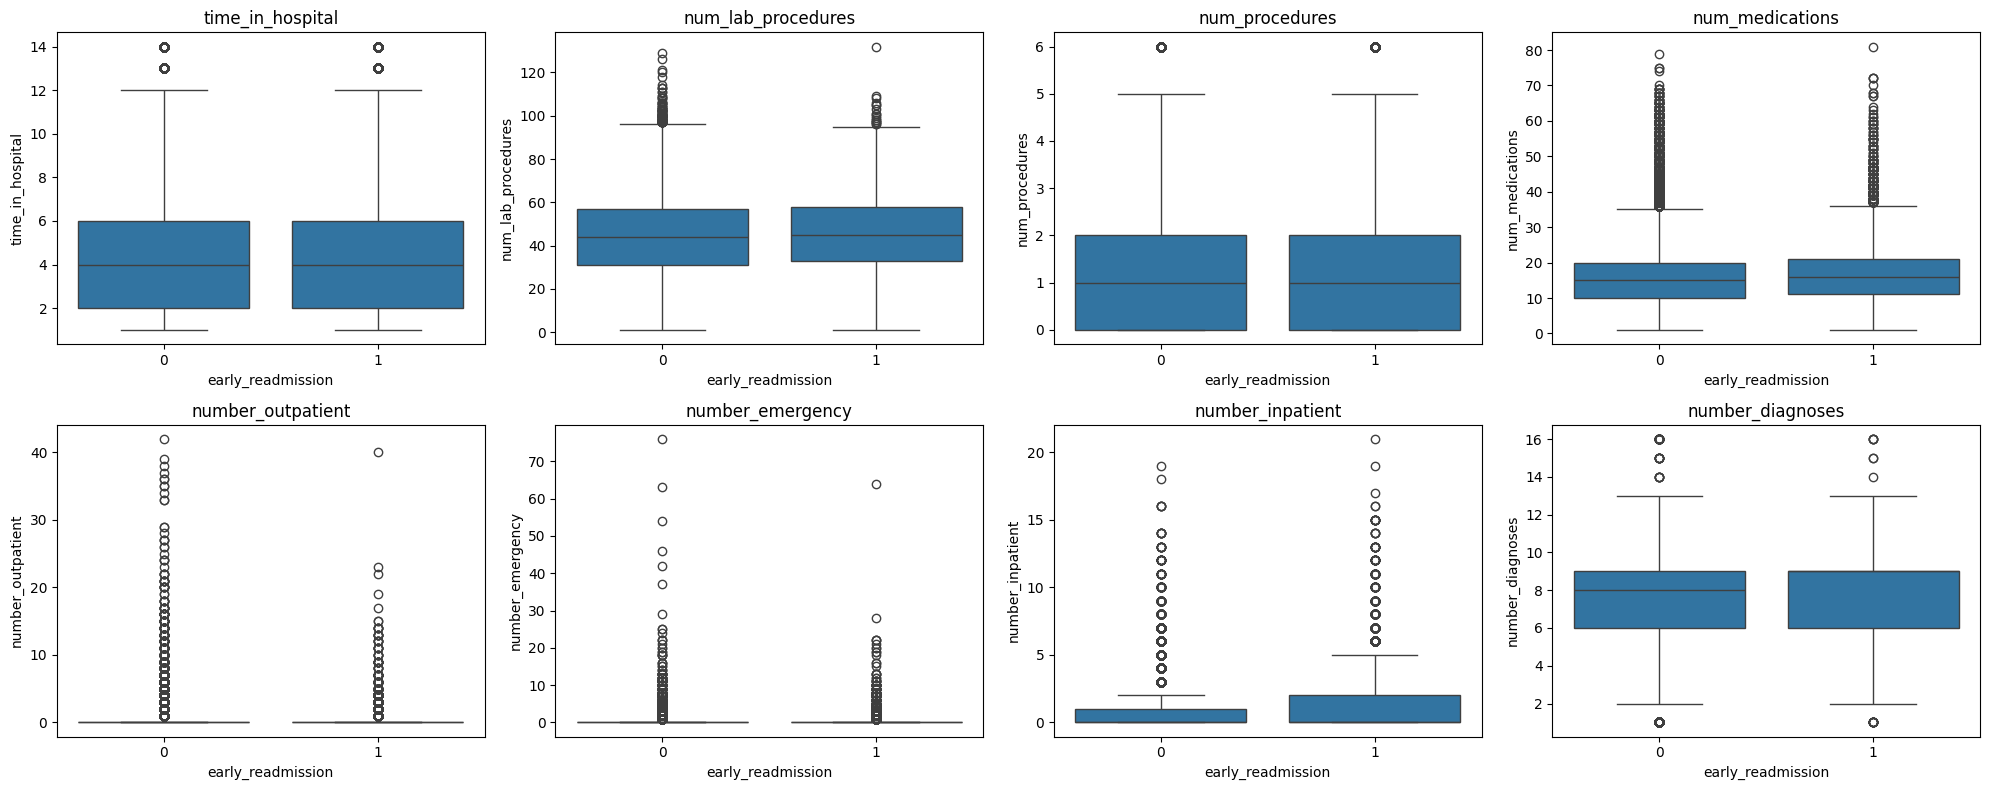

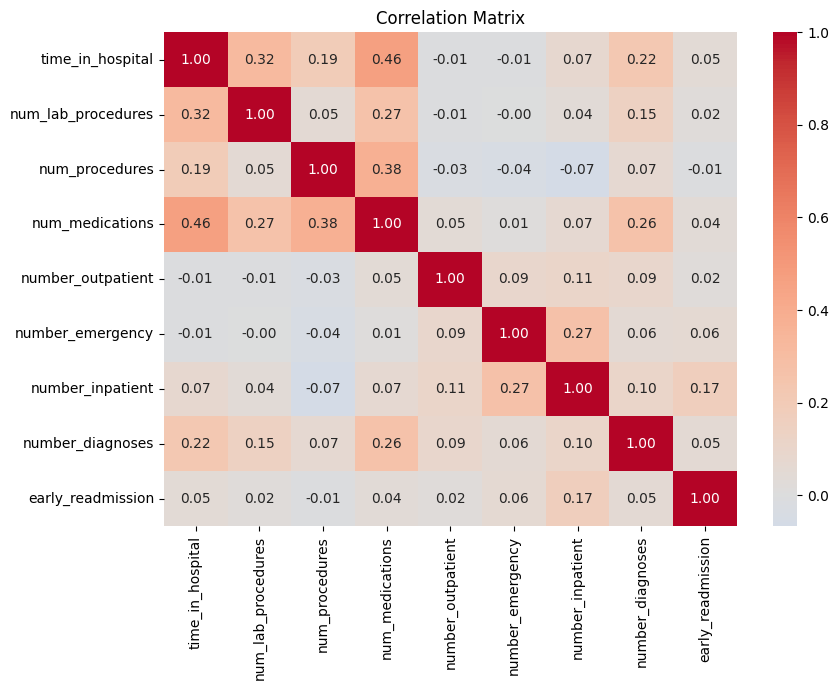


Correlation with target:
 early_readmission     1.000000
number_inpatient      0.168326
number_emergency      0.060885
number_diagnoses      0.053580
time_in_hospital      0.046886
num_medications       0.041179
num_lab_procedures    0.024044
number_outpatient     0.019169
num_procedures       -0.010841
Name: early_readmission, dtype: float64


In [7]:
def rate_table(group_col):
    t = df.groupby(group_col).agg(
        total=("early_readmission", "count"),
        readmits=("early_readmission", "sum"),
        rate_pct=("early_readmission", "mean"))
    t["rate_pct"] = (t["rate_pct"] * 100).round(2)
    return t.sort_values("rate_pct", ascending=False)

age_tab = rate_table("age")
gender_tab = rate_table("gender")
race_tab = rate_table("race")
adm_type_tab = rate_table("admission_type")
adm_src_tab = rate_table("admission_source")
disch_tab = rate_table("discharge_disposition")

print("\n--- Readmission rate by age ---\n", age_tab)
print("\n--- by gender ---\n", gender_tab)
print("\n--- by race ---\n", race_tab)
print("\n--- by admission type ---\n", adm_type_tab)
print("\n--- by discharge disposition (top 10) ---\n", disch_tab.head(10))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(x=age_tab.index, y=age_tab["rate_pct"], ax=axes[0,0]); axes[0,0].set_title("By Age"); axes[0,0].tick_params(axis='x', rotation=45)
sns.barplot(x=gender_tab.index, y=gender_tab["rate_pct"], ax=axes[0,1]); axes[0,1].set_title("By Gender")
sns.barplot(x=race_tab.index, y=race_tab["rate_pct"], ax=axes[1,0]); axes[1,0].set_title("By Race"); axes[1,0].tick_params(axis='x', rotation=45)
sns.barplot(x=adm_type_tab.index, y=adm_type_tab["rate_pct"], ax=axes[1,1]); axes[1,1].set_title("By Admission Type"); axes[1,1].tick_params(axis='x', rotation=60)
plt.tight_layout(); plt.savefig(f"{OUT}/03_demo_hosp_eda.png", dpi=110); plt.show()

numerical_features = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                       "num_medications", "number_outpatient", "number_emergency",
                       "number_inpatient", "number_diagnoses"]
print("\nNumerical feature summary:\n", df[numerical_features].describe().T)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, feat in zip(axes.ravel(), numerical_features):
    sns.boxplot(data=df, x="early_readmission", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout(); plt.savefig(f"{OUT}/04_numeric_boxplots.png", dpi=110); plt.show()

corr = df[numerical_features + ["early_readmission"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix"); plt.tight_layout()
plt.savefig(f"{OUT}/05_correlation.png", dpi=110); plt.show()
print("\nCorrelation with target:\n", corr["early_readmission"].sort_values(ascending=False))

## 13 STATISTICAL TESTS

In [8]:
def chi2_test(col):
    ct = pd.crosstab(df[col], df["early_readmission"])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    return chi2, p

cat_test_cols = ["gender", "race", "age", "admission_type", "admission_source",
                  "discharge_disposition", "A1Cresult", "insulin", "diabetesMed", "change"]
chi2_results = []
for c in cat_test_cols:
    chi2, p = chi2_test(c)
    chi2_results.append({"feature": c, "chi2": round(chi2, 2), "p_value": p})
chi2_df = pd.DataFrame(chi2_results).sort_values("chi2", ascending=False)
print("\nChi-square tests vs target:\n", chi2_df)

def mannwhitney(col):
    g0 = df.loc[df.early_readmission == 0, col]
    g1 = df.loc[df.early_readmission == 1, col]
    u, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    return u, p

mw_results = []
for c in numerical_features:
    u, p = mannwhitney(c)
    mw_results.append({"feature": c, "U": u, "p_value": p})
mw_df = pd.DataFrame(mw_results)
print("\nMann-Whitney U tests (numeric vs target):\n", mw_df)


Chi-square tests vs target:
                  feature     chi2        p_value
5  discharge_disposition  1321.31  9.526267e-269
7                insulin   199.30   5.976353e-43
2                    age   133.60   2.154572e-24
8            diabetesMed    66.77   3.056533e-16
4       admission_source    56.53   9.839925e-07
6              A1Cresult    42.56   3.055224e-09
9                 change    34.13   5.143967e-09
3         admission_type    32.36   1.391504e-05
1                   race    27.03   5.616519e-05
0                 gender     1.03   5.978601e-01



Mann-Whitney U tests (numeric vs target):
               feature            U       p_value
0    time_in_hospital  450471184.5  1.544730e-62
1  num_lab_procedures  476150647.0  2.885579e-14
2      num_procedures  501863989.5  1.519584e-01
3     num_medications  454562865.5  9.508580e-52
4   number_outpatient  477715845.5  7.582072e-28
5    number_emergency  466124710.0  1.209288e-91
6    number_inpatient  391144766.5  0.000000e+00
7    number_diagnoses  454139632.0  2.547136e-59


## 14 MULTICOLLINEARITY (VIF)

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Feature"] = numerical_features
vif_X = df[numerical_features].fillna(0).values
vif_data["VIF"] = [variance_inflation_factor(vif_X, i) for i in range(len(numerical_features))]
print("\nVIF:\n", vif_data.sort_values("VIF", ascending=False))


VIF:
               Feature       VIF
7    number_diagnoses  7.488923
3     num_medications  7.368877
1  num_lab_procedures  5.901692
0    time_in_hospital  4.337756
2      num_procedures  1.914955
6    number_inpatient  1.383345
5    number_emergency  1.132795
4   number_outpatient  1.114681


## 15 LEAKAGE CHECK

In [10]:
leakage_cols = ["readmitted", "early_readmission", "encounter_id", "patient_nbr",
                 "admission_type_id", "discharge_disposition_id", "admission_source_id"]
print("\nExcluded from modeling (target/ID/raw-id duplicates of mapped cols):", leakage_cols)


Excluded from modeling (target/ID/raw-id duplicates of mapped cols): ['readmitted', 'early_readmission', 'encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']


## 16 FEATURE ENGINEERING

In [11]:
med_cols = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
            "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
            "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
            "examide", "citoglipton", "insulin", "glyburide-metformin",
            "glipizide-metformin", "glimepiride-pioglitazone",
            "metformin-rosiglitazone", "metformin-pioglitazone"]
med_cols = [c for c in med_cols if c in df.columns]

# count of medications actually changed/prescribed (Up/Down/Steady vs No)
df["num_med_changes"] = (df[med_cols] == "Up").sum(axis=1) + (df[med_cols] == "Down").sum(axis=1)
df["num_meds_active"] = (df[med_cols] != "No").sum(axis=1)

# service utilization total (prior visits)
df["total_prior_visits"] = df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]

# ICD-9 diagnosis groups (first 3 chars, coarse grouping)
def icd9_group(code):
    if code == "Unknown" or pd.isna(code):
        return "Unknown"
    code = str(code)
    if code.startswith("V") or code.startswith("E"):
        return "Other"
    try:
        c = float(code)
    except ValueError:
        return "Other"
    if 390 <= c <= 459 or c == 785:
        return "Circulatory"
    if 460 <= c <= 519 or c == 786:
        return "Respiratory"
    if 520 <= c <= 579 or c == 787:
        return "Digestive"
    if 250 <= c < 251:
        return "Diabetes"
    if 800 <= c <= 999:
        return "Injury"
    if 710 <= c <= 739:
        return "Musculoskeletal"
    if 580 <= c <= 629 or c == 788:
        return "Genitourinary"
    if 140 <= c <= 239:
        return "Neoplasms"
    return "Other"

df["diag_1_group"] = df["diag_1"].apply(icd9_group)

# collapse rare medical_specialty / discharge / admission_source categories
def collapse_rare(series, min_count=1000, other_label="Other"):
    counts = series.value_counts()
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), other_label)

df["medical_specialty_grp"] = collapse_rare(df["medical_specialty"], 1000)
df["discharge_disposition_grp"] = collapse_rare(df["discharge_disposition"], 1000)
df["admission_source_grp"] = collapse_rare(df["admission_source"], 1000)

print("\ndiag_1_group counts:\n", df["diag_1_group"].value_counts())
print("\nnum_med_changes describe:\n", df["num_med_changes"].describe())

model_categorical = ["race", "gender", "age", "admission_type", "admission_source_grp",
                      "discharge_disposition_grp", "medical_specialty_grp",
                      "A1Cresult", "diag_1_group", "insulin", "change", "diabetesMed"]
model_numerical = numerical_features + ["num_med_changes", "num_meds_active", "total_prior_visits"]

feature_cols = model_categorical + model_numerical
X = df[feature_cols].copy()
y = df["early_readmission"].copy()
groups = df["patient_nbr"].copy()


diag_1_group counts:
 diag_1_group
Circulatory        29681
Other              17793
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6853
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Unknown               20
Name: count, dtype: int64

num_med_changes describe:
 count    99343.000000
mean         0.287368
std          0.487861
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          4.000000
Name: num_med_changes, dtype: float64


## 17 TRAIN/TEST SPLIT (patient-level, no leakage across split)

In [12]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print("Train target rate: %.2f%%  Test target rate: %.2f%%" % (y_train.mean()*100, y_test.mean()*100))
assert set(df.loc[train_idx, "patient_nbr"]).isdisjoint(set(df.loc[test_idx, "patient_nbr"]))
print("Confirmed: no patient appears in both train and test.")


Train: (79541, 23), Test: (19802, 23)
Train target rate: 11.44%  Test target rate: 11.19%
Confirmed: no patient appears in both train and test.


## 18 PREPROCESSING PIPELINE

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, model_numerical),
    ("cat", categorical_pipe, model_categorical)
])

## 19-22 BASELINE + MODELS

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report)

results = []

def evaluate(name, y_true, y_pred, y_proba):
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC_AUC": round(roc_auc_score(y_true, y_proba), 4),
        "PR_AUC": round(average_precision_score(y_true, y_proba), 4),
    })
    print(f"\n--- {name} ---")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

# Baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_proba = dummy.predict_proba(X_test)[:, 1]
evaluate("Baseline (majority class)", y_test, dummy_pred, dummy_proba)

# Logistic Regression
logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])
logreg.fit(X_train, y_train)
lr_proba = logreg.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= 0.5).astype(int)
evaluate("Logistic Regression", y_test, lr_pred, lr_proba)

# Random Forest
rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                                    class_weight="balanced", random_state=42, n_jobs=-1))
])
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)
evaluate("Random Forest", y_test, rf_pred, rf_proba)

# CatBoost (handles categoricals natively, so give it raw columns)
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()
for c in model_categorical:
    X_train_cb[c] = X_train_cb[c].astype(str).fillna("Unknown")
    X_test_cb[c] = X_test_cb[c].astype(str).fillna("Unknown")
for c in model_numerical:
    X_train_cb[c] = X_train_cb[c].fillna(X_train_cb[c].median())
    X_test_cb[c] = X_test_cb[c].fillna(X_train_cb[c].median())

cat_features_idx = [X_train_cb.columns.get_loc(c) for c in model_categorical]
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
cb = CatBoostClassifier(iterations=400, depth=6, learning_rate=0.05,
                         eval_metric="AUC", scale_pos_weight=pos_weight,
                         random_seed=42, verbose=False)
cb.fit(X_train_cb, y_train, cat_features=cat_features_idx)
cb_proba = cb.predict_proba(X_test_cb)[:, 1]
cb_pred = (cb_proba >= 0.5).astype(int)
evaluate("CatBoost", y_test, cb_pred, cb_proba)


--- Baseline (majority class) ---
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17586
           1       0.00      0.00      0.00      2216

    accuracy                           0.89     19802
   macro avg       0.44      0.50      0.47     19802
weighted avg       0.79      0.89      0.84     19802

Confusion matrix:
 [[17586     0]
 [ 2216     0]]



--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     17586
           1       0.18      0.53      0.27      2216

    accuracy                           0.67     19802
   macro avg       0.55      0.61      0.53     19802
weighted avg       0.84      0.67      0.73     19802

Confusion matrix:
 [[12139  5447]
 [ 1038  1178]]



--- Random Forest ---
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     17586
           1       0.19      0.53      0.27      2216

    accuracy                           0.69     19802
   macro avg       0.55      0.62      0.54     19802
weighted avg       0.84      0.69      0.74     19802

Confusion matrix:
 [[12473  5113]
 [ 1049  1167]]



--- CatBoost ---
              precision    recall  f1-score   support

           0       0.93      0.67      0.77     17586
           1       0.18      0.58      0.27      2216

    accuracy                           0.66     19802
   macro avg       0.55      0.62      0.52     19802
weighted avg       0.84      0.66      0.72     19802

Confusion matrix:
 [[11707  5879]
 [  941  1275]]


## 23 MODEL COMPARISON


=== MODEL COMPARISON ===
                     Model  Accuracy  Precision  Recall     F1  ROC_AUC  PR_AUC
Baseline (majority class)    0.8881     0.0000  0.0000 0.0000   0.5000  0.1119
      Logistic Regression    0.6725     0.1778  0.5316 0.2665   0.6606  0.2122
            Random Forest    0.6888     0.1858  0.5266 0.2747   0.6654  0.2192
                 CatBoost    0.6556     0.1782  0.5754 0.2721   0.6681  0.2291


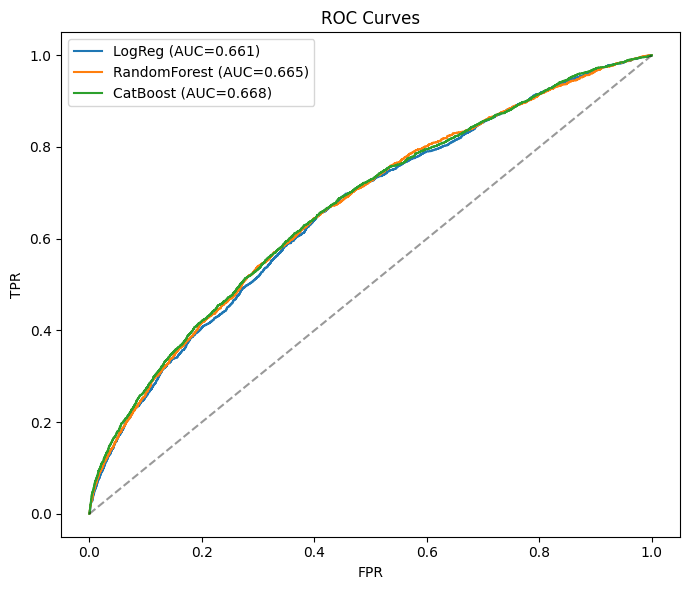

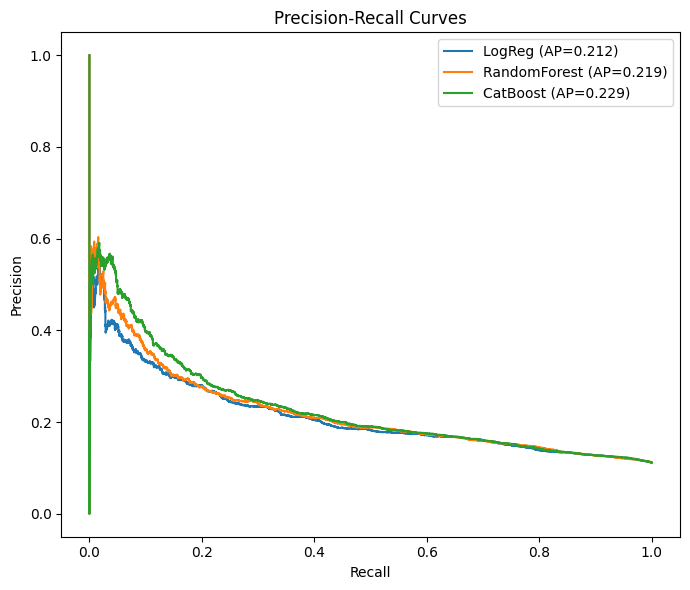

In [15]:
results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON ===\n", results_df.to_string(index=False))
results_df.to_csv(f"{OUT}/model_comparison.csv", index=False)

# ROC + PR curves
from sklearn.metrics import roc_curve, precision_recall_curve
plt.figure(figsize=(7, 6))
for name, proba in [("LogReg", lr_proba), ("RandomForest", rf_proba), ("CatBoost", cb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curves"); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/06_roc_curves.png", dpi=110); plt.show()

plt.figure(figsize=(7, 6))
for name, proba in [("LogReg", lr_proba), ("RandomForest", rf_proba), ("CatBoost", cb_proba)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curves"); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/07_pr_curves.png", dpi=110); plt.show()

## 25 FEATURE IMPORTANCE (best model = CatBoost, by PR-AUC typically)


Best model by PR-AUC: CatBoost

CatBoost feature importance (top 15):
 discharge_disposition_grp    13.404938
number_inpatient             10.267309
diag_1_group                  7.758578
num_lab_procedures            6.993454
num_medications               6.623344
age                           6.329934
time_in_hospital              5.906102
number_diagnoses              4.804220
total_prior_visits            4.699383
medical_specialty_grp         4.536316
num_procedures                3.338282
admission_source_grp          3.210599
insulin                       3.188364
admission_type                3.131548
num_meds_active               2.954927
dtype: float64


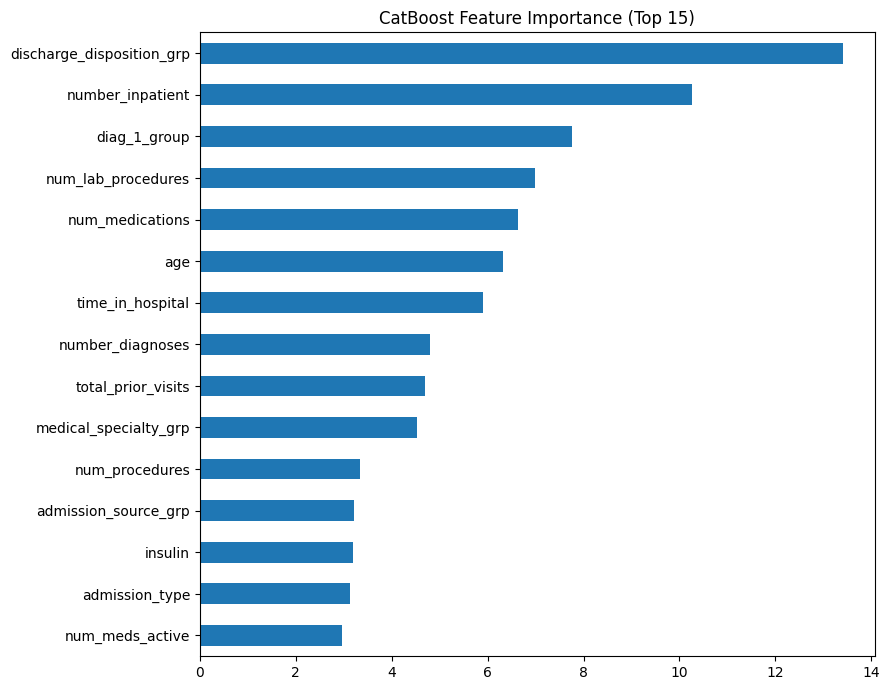

In [16]:
best_row = results_df[results_df.Model != "Baseline (majority class)"].sort_values("PR_AUC", ascending=False).iloc[0]
print("\nBest model by PR-AUC:", best_row["Model"])

cb_importance = pd.Series(cb.get_feature_importance(), index=X_train_cb.columns).sort_values(ascending=False)
print("\nCatBoost feature importance (top 15):\n", cb_importance.head(15))

plt.figure(figsize=(9, 7))
cb_importance.head(15).sort_values().plot(kind="barh")
plt.title("CatBoost Feature Importance (Top 15)"); plt.tight_layout()
plt.savefig(f"{OUT}/08_feature_importance.png", dpi=110); plt.show()

## 26 FINAL PREDICTIONS + RISK LEVELS  (use CatBoost as final model)

In [17]:
final_proba_all = cb.predict_proba(pd.concat([X_train_cb, X_test_cb])[X_train_cb.columns])[:, 1]
full_idx = list(train_idx) + list(test_idx)

powerbi_df = df.loc[full_idx, ["encounter_id", "patient_nbr", "age", "gender", "race",
                                "admission_type", "discharge_disposition", "admission_source",
                                "time_in_hospital", "num_medications", "number_diagnoses"]].copy()
powerbi_df["actual_readmission"] = df.loc[full_idx, "early_readmission"].values
powerbi_df["readmission_probability"] = final_proba_all
powerbi_df["predicted_readmission"] = (powerbi_df["readmission_probability"] >= 0.5).astype(int)
powerbi_df["set"] = ["train"] * len(train_idx) + ["test"] * len(test_idx)

q1, q2 = powerbi_df["readmission_probability"].quantile([0.5, 0.85])
def risk_level(p):
    if p < q1: return "Low"
    if p < q2: return "Medium"
    return "High"
powerbi_df["risk_level"] = powerbi_df["readmission_probability"].apply(risk_level)

print("\nRisk level thresholds -> Low: <%.3f, Medium: %.3f-%.3f, High: >=%.3f" % (q1, q1, q2, q2))
print(powerbi_df["risk_level"].value_counts())

powerbi_df.to_csv(f"{OUT}/readmission_predictions.csv", index=False)
print("\nPower BI dataset exported to outputs/readmission_predictions.csv")

# Save summary json for quick reference
summary = {
    "rows_original": int(101766),
    "rows_after_cleaning": int(len(df)),
    "features_used": feature_cols,
    "model_comparison": results_df.to_dict(orient="records"),
    "risk_thresholds": {"low_max": float(q1), "medium_max": float(q2)},
}
with open(f"{OUT}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nPIPELINE COMPLETE.")


Risk level thresholds -> Low: <0.444, Medium: 0.444-0.613, High: >=0.613
risk_level
Low       49671
Medium    34770
High      14902
Name: count, dtype: int64



Power BI dataset exported to outputs/readmission_predictions.csv

PIPELINE COMPLETE.


# Model Improvement

Continuation of the main notebook: cross-validation, threshold optimization, hyperparameter tuning, feature re-selection, final locked model, and re-exported predictions.

## Rebuild dataset and features

In [1]:
"""
Model Improvement — steps 1-6 (lean version, tuned for a single-core sandbox)
1. Cross-validate current models (3-fold, patient-grouped, stratified)
2. Optimize decision threshold (reuses CatBoost OOF predictions from step 1)
3. Tune hyperparameters (small randomized search, CatBoost)
4. Re-run feature selection (drop low-importance features, compare CV PR-AUC)
5. Lock final model, evaluate once on held-out test set
6. Re-generate predictions + risk tiers
"""
import warnings, json, time
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT = "outputs"
T0 = time.time()
def log(msg):
    print(f"[{time.time()-T0:6.1f}s] {msg}", flush=True)

# =================================================================
# Rebuild the exact same cleaned dataset / features / split as pipeline.py
# =================================================================
df = pd.read_csv("data/diabetic_data.csv", na_values="?")
mapping_df = pd.read_csv("data/IDS_mapping.csv")
df["early_readmission"] = (df["readmitted"] == "<30").astype(int)

def build_mapping(mapping_df, key_col):
    col0 = mapping_df.iloc[:, 0].astype(str)
    start = 0 if key_col == mapping_df.columns[0] else mapping_df.index[col0 == key_col][0] + 1
    matches = mapping_df.index[(col0 == "discharge_disposition_id") | (col0 == "admission_source_id")]
    later = [i for i in matches if i > start]
    end = min(later) if later else len(mapping_df)
    sub = mapping_df.iloc[start:end]
    sub = sub[sub.iloc[:, 0].notna()]
    d = {}
    for _, row in sub.iterrows():
        try:
            d[int(float(row.iloc[0]))] = row.iloc[1]
        except (ValueError, TypeError):
            continue
    return d

df["admission_type"] = df["admission_type_id"].map(build_mapping(mapping_df, "admission_type_id"))
df["discharge_disposition"] = df["discharge_disposition_id"].map(build_mapping(mapping_df, "discharge_disposition_id"))
df["admission_source"] = df["admission_source_id"].map(build_mapping(mapping_df, "admission_source_id"))

df = df.drop(columns=["weight", "max_glu_serum"])
for c in ["A1Cresult", "medical_specialty", "payer_code", "race", "diag_1", "diag_2", "diag_3"]:
    df[c] = df[c].fillna("Unknown" if c != "A1Cresult" else "Not Tested")

expired_hospice_ids = [11, 13, 14, 19, 20, 21]
df = df[~df["discharge_disposition_id"].isin(expired_hospice_ids)].copy().reset_index(drop=True)

med_cols = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
            "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
            "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
            "examide", "citoglipton", "insulin", "glyburide-metformin",
            "glipizide-metformin", "glimepiride-pioglitazone",
            "metformin-rosiglitazone", "metformin-pioglitazone"]
med_cols = [c for c in med_cols if c in df.columns]
df["num_med_changes"] = (df[med_cols] == "Up").sum(axis=1) + (df[med_cols] == "Down").sum(axis=1)
df["num_meds_active"] = (df[med_cols] != "No").sum(axis=1)
df["total_prior_visits"] = df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]

def icd9_group(code):
    if code == "Unknown" or pd.isna(code):
        return "Unknown"
    code = str(code)
    if code.startswith("V") or code.startswith("E"):
        return "Other"
    try:
        c = float(code)
    except ValueError:
        return "Other"
    if 390 <= c <= 459 or c == 785: return "Circulatory"
    if 460 <= c <= 519 or c == 786: return "Respiratory"
    if 520 <= c <= 579 or c == 787: return "Digestive"
    if 250 <= c < 251: return "Diabetes"
    if 800 <= c <= 999: return "Injury"
    if 710 <= c <= 739: return "Musculoskeletal"
    if 580 <= c <= 629 or c == 788: return "Genitourinary"
    if 140 <= c <= 239: return "Neoplasms"
    return "Other"

df["diag_1_group"] = df["diag_1"].apply(icd9_group)

def collapse_rare(series, min_count=1000, other_label="Other"):
    counts = series.value_counts()
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), other_label)

df["medical_specialty_grp"] = collapse_rare(df["medical_specialty"], 1000)
df["discharge_disposition_grp"] = collapse_rare(df["discharge_disposition"], 1000)
df["admission_source_grp"] = collapse_rare(df["admission_source"], 1000)

numerical_features = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                       "num_medications", "number_outpatient", "number_emergency",
                       "number_inpatient", "number_diagnoses"]
model_categorical = ["race", "gender", "age", "admission_type", "admission_source_grp",
                      "discharge_disposition_grp", "medical_specialty_grp",
                      "A1Cresult", "diag_1_group", "insulin", "change", "diabetesMed"]
model_numerical = numerical_features + ["num_med_changes", "num_meds_active", "total_prior_visits"]
feature_cols = model_categorical + model_numerical

X = df[feature_cols].copy()
y = df["early_readmission"].copy()
groups = df["patient_nbr"].copy()

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_train = groups.iloc[train_idx].reset_index(drop=True)
log(f"Train: {X_train.shape}, Test: {X_test.shape}")

def to_cb(Xdf):
    out = Xdf.copy()
    for c in model_categorical:
        if c in out.columns:
            out[c] = out[c].astype(str).fillna("Unknown")
    for c in model_numerical:
        if c in out.columns:
            out[c] = out[c].fillna(out[c].median())
    return out

X_train_cb = to_cb(X_train)
X_test_cb = to_cb(X_test)
cat_idx = [X_train_cb.columns.get_loc(c) for c in model_categorical]

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                              recall_score, f1_score, confusion_matrix, classification_report)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), model_numerical),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), model_categorical)
])

# ---------------------------------------------------------------
# 1) + 2) CROSS-VALIDATE + collect CatBoost OOF probabilities for threshold tuning
#    (3-fold, patient-grouped & stratified; single combined pass — single CPU core)
# ---------------------------------------------------------------
skf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
cv_results = {"LogReg": {"roc": [], "pr": []}, "RandomForest": {"roc": [], "pr": []}, "CatBoost": {"roc": [], "pr": []}}
oof_proba = np.zeros(len(X_train))

for fold, (tr, va) in enumerate(skf.split(X_train, y_train, groups_train)):
    Xt, Xv = X_train.iloc[tr], X_train.iloc[va]
    yt, yv = y_train.iloc[tr], y_train.iloc[va]

    lr = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))])
    lr.fit(Xt, yt)
    p = lr.predict_proba(Xv)[:, 1]
    cv_results["LogReg"]["roc"].append(roc_auc_score(yv, p)); cv_results["LogReg"]["pr"].append(average_precision_score(yv, p))
    log(f"Fold {fold+1}/3 — LogReg done")

    rf = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(n_estimators=120, max_depth=10, min_samples_leaf=30, class_weight="balanced", random_state=42, n_jobs=-1))])
    rf.fit(Xt, yt)
    p = rf.predict_proba(Xv)[:, 1]
    cv_results["RandomForest"]["roc"].append(roc_auc_score(yv, p)); cv_results["RandomForest"]["pr"].append(average_precision_score(yv, p))
    log(f"Fold {fold+1}/3 — RandomForest done")

    Xt_cb, Xv_cb = to_cb(Xt), to_cb(Xv)
    pw = (yt == 0).sum() / (yt == 1).sum()
    cb = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.08, eval_metric="AUC",
                             scale_pos_weight=pw, random_seed=42, verbose=False)
    cb.fit(Xt_cb, yt, cat_features=cat_idx)
    p = cb.predict_proba(Xv_cb)[:, 1]
    oof_proba[va] = p
    cv_results["CatBoost"]["roc"].append(roc_auc_score(yv, p)); cv_results["CatBoost"]["pr"].append(average_precision_score(yv, p))
    log(f"Fold {fold+1}/3 — CatBoost done")

cv_summary = pd.DataFrame({
    m: {"ROC_AUC_mean": np.mean(v["roc"]), "ROC_AUC_std": np.std(v["roc"]),
        "PR_AUC_mean": np.mean(v["pr"]), "PR_AUC_std": np.std(v["pr"])}
    for m, v in cv_results.items()
}).T
log("=== 3-FOLD CV RESULTS (patient-grouped) ===")
print(cv_summary.round(4))
cv_summary.to_csv(f"{OUT}/cv_results.csv")

[   2.3s] Train: (79541, 23), Test: (19802, 23)


[   8.6s] Fold 1/3 — LogReg done


[  25.3s] Fold 1/3 — RandomForest done


[  45.2s] Fold 1/3 — CatBoost done


[  46.0s] Fold 2/3 — LogReg done


...

[  83.2s] Fold 3/3 — LogReg done


[  99.8s] Fold 3/3 — RandomForest done


[ 119.9s] Fold 3/3 — CatBoost done


[ 119.9s] === 3-FOLD CV RESULTS (patient-grouped) ===


              ROC_AUC_mean  ROC_AUC_std  PR_AUC_mean  PR_AUC_std
LogReg              0.6604       0.0127       0.2107      0.0095
RandomForest        0.6667       0.0131       0.2144      0.0112
CatBoost            0.6688       0.0105       0.2203      0.0086


## 2) THRESHOLD OPTIMIZATION using the CatBoost OOF probabilities above

[ 121.4s] === THRESHOLD SWEEP ===


Best F1 threshold:
 threshold    0.540000
precision    0.201803
recall       0.460211
f1           0.280574
Name: 13, dtype: float64

Highest-precision threshold with recall>=0.70:
    threshold  precision    recall        f1
9       0.42    0.15514  0.753242  0.257288


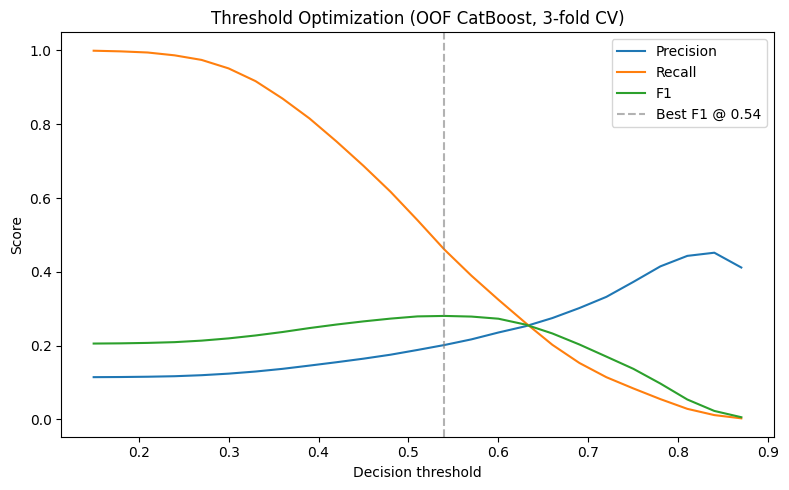

[ 121.6s] Chosen operating threshold: 0.54


In [2]:
thresholds = np.arange(0.15, 0.9, 0.03)
thr_rows = []
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    thr_rows.append({"threshold": round(t, 2),
                      "precision": precision_score(y_train, pred, zero_division=0),
                      "recall": recall_score(y_train, pred, zero_division=0),
                      "f1": f1_score(y_train, pred, zero_division=0)})
thr_df = pd.DataFrame(thr_rows)
best_f1_row = thr_df.loc[thr_df["f1"].idxmax()]
recall70 = thr_df[thr_df["recall"] >= 0.70].sort_values("precision", ascending=False).head(1)
log("=== THRESHOLD SWEEP ===")
print("Best F1 threshold:\n", best_f1_row)
print("\nHighest-precision threshold with recall>=0.70:\n", recall70)

plt.figure(figsize=(8, 5))
plt.plot(thr_df["threshold"], thr_df["precision"], label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"], label="F1")
plt.axvline(best_f1_row["threshold"], color="gray", linestyle="--", alpha=0.6, label=f"Best F1 @ {best_f1_row['threshold']}")
plt.xlabel("Decision threshold"); plt.ylabel("Score"); plt.legend(); plt.title("Threshold Optimization (OOF CatBoost, 3-fold CV)")
plt.tight_layout(); plt.savefig(f"{OUT}/09_threshold_sweep.png", dpi=110); plt.show()

CHOSEN_THRESHOLD = float(best_f1_row["threshold"])
log(f"Chosen operating threshold: {CHOSEN_THRESHOLD}")

## 3) HYPERPARAMETER TUNING — small randomized search, 2-fold CV, scored on PR-AUC

In [3]:
import itertools, random
random.seed(42)
param_grid = {"depth": [4, 6, 8], "learning_rate": [0.05, 0.1], "l2_leaf_reg": [1, 5], "iterations": [200, 350]}
all_combos = list(itertools.product(*param_grid.values()))
random.shuffle(all_combos)
search_combos = all_combos[:5]

skf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
tuning_rows = []
for combo in search_combos:
    params = dict(zip(param_grid.keys(), combo))
    fold_pr = []
    for tr, va in skf2.split(X_train, y_train, groups_train):
        Xt_cb, Xv_cb = to_cb(X_train.iloc[tr]), to_cb(X_train.iloc[va])
        yt, yv = y_train.iloc[tr], y_train.iloc[va]
        pw = (yt == 0).sum() / (yt == 1).sum()
        cb = CatBoostClassifier(**params, eval_metric="AUC", scale_pos_weight=pw, random_seed=42, verbose=False)
        cb.fit(Xt_cb, yt, cat_features=cat_idx)
        fold_pr.append(average_precision_score(yv, cb.predict_proba(Xv_cb)[:, 1]))
    tuning_rows.append({**params, "mean_PR_AUC": np.mean(fold_pr)})
    log(f"Tuning combo {params} -> PR-AUC {np.mean(fold_pr):.4f}")

tuning_df = pd.DataFrame(tuning_rows).sort_values("mean_PR_AUC", ascending=False)
log("=== HYPERPARAMETER SEARCH RESULTS ===")
print(tuning_df.to_string(index=False))
tuning_df.to_csv(f"{OUT}/hyperparam_search.csv", index=False)

best_params = tuning_df.iloc[0][list(param_grid.keys())].to_dict()
best_params = {"depth": int(best_params["depth"]), "learning_rate": float(best_params["learning_rate"]),
                "l2_leaf_reg": int(best_params["l2_leaf_reg"]), "iterations": int(best_params["iterations"])}
log(f"Best hyperparameters: {best_params}")

[ 181.1s] Tuning combo {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 350} -> PR-AUC 0.2155


[ 223.4s] Tuning combo {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 350} -> PR-AUC 0.2161


[ 265.9s] Tuning combo {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200} -> PR-AUC 0.2198


[ 349.9s] Tuning combo {'depth': 8, 'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 350} -> PR-AUC 0.2108


[ 409.6s] Tuning combo {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 350} -> PR-AUC 0.2164


[ 409.6s] === HYPERPARAMETER SEARCH RESULTS ===


 depth  learning_rate  l2_leaf_reg  iterations  mean_PR_AUC
     8           0.05            5         200     0.219846
     6           0.10            1         350     0.216431
     4           0.10            1         350     0.216061
     6           0.10            5         350     0.215526
     8           0.10            5         350     0.210790
[ 409.6s] Best hyperparameters: {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200}


## 4) FEATURE RE-SELECTION — drop lowest-importance features, compare 2-fold CV PR-AUC

In [4]:
pw_full = (y_train == 0).sum() / (y_train == 1).sum()
cb_full = CatBoostClassifier(**best_params, eval_metric="AUC", scale_pos_weight=pw_full, random_seed=42, verbose=False)
cb_full.fit(X_train_cb, y_train, cat_features=cat_idx)
importance = pd.Series(cb_full.get_feature_importance(), index=X_train_cb.columns).sort_values(ascending=False)
log("Full-feature importance:")
print(importance)

low_importance = importance.tail(4).index.tolist()
log(f"Candidates to drop (lowest importance): {low_importance}")

reduced_features = [c for c in feature_cols if c not in low_importance]
reduced_categorical = [c for c in model_categorical if c in reduced_features]
reduced_cat_idx = [i for i, c in enumerate(reduced_features) if c in reduced_categorical]

fold_pr_full, fold_pr_reduced = [], []
for tr, va in skf2.split(X_train, y_train, groups_train):
    yt, yv = y_train.iloc[tr], y_train.iloc[va]
    pw = (yt == 0).sum() / (yt == 1).sum()

    Xt_full, Xv_full = to_cb(X_train.iloc[tr]), to_cb(X_train.iloc[va])
    cb_a = CatBoostClassifier(**best_params, eval_metric="AUC", scale_pos_weight=pw, random_seed=42, verbose=False)
    cb_a.fit(Xt_full, yt, cat_features=cat_idx)
    fold_pr_full.append(average_precision_score(yv, cb_a.predict_proba(Xv_full)[:, 1]))

    Xt_red, Xv_red = to_cb(X_train.iloc[tr][reduced_features]), to_cb(X_train.iloc[va][reduced_features])
    cb_b = CatBoostClassifier(**best_params, eval_metric="AUC", scale_pos_weight=pw, random_seed=42, verbose=False)
    cb_b.fit(Xt_red, yt, cat_features=reduced_cat_idx)
    fold_pr_reduced.append(average_precision_score(yv, cb_b.predict_proba(Xv_red)[:, 1]))

log(f"Full feature set PR-AUC:    {np.mean(fold_pr_full):.4f}")
log(f"Reduced feature set PR-AUC: {np.mean(fold_pr_reduced):.4f}")

if np.mean(fold_pr_reduced) >= np.mean(fold_pr_full) - 0.002:
    FINAL_FEATURES, FINAL_CAT_IDX = reduced_features, reduced_cat_idx
    log("Decision: keep REDUCED feature set (comparable performance, simpler model).")
else:
    FINAL_FEATURES, FINAL_CAT_IDX = feature_cols, cat_idx
    log("Decision: keep FULL feature set (dropping features hurt performance).")

[ 447.5s] Full-feature importance:


discharge_disposition_grp    15.867719
number_inpatient             13.431382
medical_specialty_grp         6.497464
diag_1_group                  6.474078
total_prior_visits            5.558849
age                           5.044755
number_diagnoses              4.741613
A1Cresult                     4.371752
admission_type                3.960328
time_in_hospital              3.950879
num_medications               3.346439
insulin                       3.299290
admission_source_grp          3.279887
num_meds_active               3.152810
race                          3.096084
num_lab_procedures            3.041319
gender                        2.972528
diabetesMed                   2.080490
number_emergency              1.418144
number_outpatient             1.298742
num_procedures                1.261247
num_med_changes               0.936779
change                        0.917422
dtype: float64
[ 447.5s] Candidates to drop (lowest importance): ['number_outpatient', 'num_procedures'

[ 530.1s] Full feature set PR-AUC:    0.2198


[ 530.1s] Reduced feature set PR-AUC: 0.2207


[ 530.1s] Decision: keep REDUCED feature set (comparable performance, simpler model).


## 5) LOCK FINAL MODEL — retrain on full train set, evaluate ONCE on held-out test

In [5]:
X_train_final = to_cb(X_train[FINAL_FEATURES])
X_test_final = to_cb(X_test[FINAL_FEATURES])
pw_final = (y_train == 0).sum() / (y_train == 1).sum()
final_model = CatBoostClassifier(**best_params, eval_metric="AUC", scale_pos_weight=pw_final, random_seed=42, verbose=False)
final_model.fit(X_train_final, y_train, cat_features=FINAL_CAT_IDX)

final_proba_test = final_model.predict_proba(X_test_final)[:, 1]
final_pred_test = (final_proba_test >= CHOSEN_THRESHOLD).astype(int)

log("=== FINAL MODEL — HELD-OUT TEST SET (evaluated once) ===")
print("Params:", best_params, "| Threshold:", CHOSEN_THRESHOLD, "| Features:", len(FINAL_FEATURES))
print("ROC-AUC:", round(roc_auc_score(y_test, final_proba_test), 4))
print("PR-AUC :", round(average_precision_score(y_test, final_proba_test), 4))
print(classification_report(y_test, final_pred_test, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, final_pred_test))

final_summary = {
    "best_params": best_params, "chosen_threshold": CHOSEN_THRESHOLD, "final_features": FINAL_FEATURES,
    "test_roc_auc": float(roc_auc_score(y_test, final_proba_test)),
    "test_pr_auc": float(average_precision_score(y_test, final_proba_test)),
    "test_precision": float(precision_score(y_test, final_pred_test, zero_division=0)),
    "test_recall": float(recall_score(y_test, final_pred_test, zero_division=0)),
    "test_f1": float(f1_score(y_test, final_pred_test, zero_division=0)),
}
with open(f"{OUT}/final_model_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)
log("Saved final_model_summary.json")

[ 566.7s] === FINAL MODEL — HELD-OUT TEST SET (evaluated once) ===


Params: {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200} | Threshold: 0.54 | Features: 19
ROC-AUC: 0.6699
PR-AUC : 0.2285
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     17586
           1       0.20      0.47      0.28      2216

    accuracy                           0.72     19802
   macro avg       0.56      0.61      0.55     19802
weighted avg       0.84      0.72      0.77     19802

Confusion matrix:
 [[13271  4315]
 [ 1165  1051]]
[ 566.7s] Saved final_model_summary.json


## 6) RE-GENERATE PREDICTIONS + RISK TIERS (full dataset, final model, chosen threshold)

In [6]:
X_all_final = to_cb(pd.concat([X_train[FINAL_FEATURES], X_test[FINAL_FEATURES]], ignore_index=True))
full_idx = list(train_idx) + list(test_idx)
final_proba_all = final_model.predict_proba(X_all_final)[:, 1]

powerbi_df = df.loc[full_idx, ["encounter_id", "patient_nbr", "age", "gender", "race",
                                "admission_type", "discharge_disposition", "admission_source",
                                "time_in_hospital", "num_medications", "number_diagnoses"]].copy()
powerbi_df["actual_readmission"] = df.loc[full_idx, "early_readmission"].values
powerbi_df["readmission_probability"] = final_proba_all
powerbi_df["predicted_readmission"] = (powerbi_df["readmission_probability"] >= CHOSEN_THRESHOLD).astype(int)
powerbi_df["set"] = ["train"] * len(train_idx) + ["test"] * len(test_idx)

q1, q2 = powerbi_df["readmission_probability"].quantile([0.5, 0.85])
def risk_level(p):
    if p < q1: return "Low"
    if p < q2: return "Medium"
    return "High"
powerbi_df["risk_level"] = powerbi_df["readmission_probability"].apply(risk_level)

log("Final risk tier counts:")
print(powerbi_df["risk_level"].value_counts())
powerbi_df.to_csv(f"{OUT}/readmission_predictions_final.csv", index=False)
log("Saved outputs/readmission_predictions_final.csv (tuned model, optimized threshold)")
log("MODEL IMPROVEMENT COMPLETE.")

[ 567.3s] Final risk tier counts:


risk_level
Low       49671
Medium    34770
High      14902
Name: count, dtype: int64


[ 567.8s] Saved outputs/readmission_predictions_final.csv (tuned model, optimized threshold)


[ 567.8s] MODEL IMPROVEMENT COMPLETE.
